# Mass Balance

### Connor van Wieren, 2025

In [1]:
todays_date = str(datetime.now())[:16] # lim  it to minutes`
display(Markdown(f'### Date: {todays_date}'))
print(f'detected theme = {current_theme}')
plt.style.use(light_style)

### Date: 2025-04-02 13:09

detected theme = light


## Imports

**Model source:** this notebook imports the tracer-advection/diffusion sediment transport model from [TracerDiff](https://github.com/VanWieren/TracerDiff), the actively maintained, installable package version of the model used in this paper (van Wieren et al., 2026, EPSL, https://doi.org/10.1016/j.epsl.2025.119745). Install it first with:

```bash
git clone https://github.com/VanWieren/TracerDiff.git
cd TracerDiff
pip install -e .
```

In [2]:
import pandas as pd
from tqdm.notebook import tqdm
#from pypalettes import load_cmap # for color palettes
import jax
import jax.numpy as jnp
from jax import  jit, random, lax, vmap
from jax.scipy.integrate import trapezoid as trapz
jax.config.update('jax_platform_name', 'cpu')
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib
import matplotlib.ticker as ticker
from matplotlib.colors import ListedColormap
import matplotlib.patches as patches
from matplotlib.ticker import ScalarFormatter
from matplotlib.lines import Line2D
from cycler import cycler
import seaborn as sns
import pandas as pd 
import time
import os
from scipy import signal
from scipy.stats import norm, uniform, gaussian_kde
from scipy.ndimage import uniform_filter1d
from scipy.ndimage import gaussian_filter
from scipy.stats import spearmanr
from scipy.ndimage import gaussian_filter
from scipy.interpolate import interp1d
import rasterio
import pickle
import dill
import sys
import string

matplotlib.rcParams['pdf.fonttype'] = 42  # for acrobat? idk why i need this

# load the TracerDiff model (https://github.com/VanWieren/TracerDiff)
# install locally with: pip install -e /path/to/TracerDiff  (see the TracerDiff README for full instructions)
from tracerdiff import run, Model_output
from tracerdiff.utils import *

# import facies
sys.path.insert(0, '/Users/cvanwieren/Library/CloudStorage/Dropbox/GitHub/Paleozoic_CIEs/notebooks/')
from facies import facies

# interactive plots
from ipywidgets import interactive, interact
from IPython.display import clear_output, Video

np.set_printoptions(threshold=np.inf,linewidth=np.inf)

# fig_dir = '/Users/cvanwieren/Library/CloudStorage/Dropbox/GitHub/Paleozoic_CIEs/figures/'
tex_fig_dir = '/Users/cvanwieren/Library/CloudStorage/Dropbox/GitHub/Publications/Paleozoic_CIE_EPSL/img/'

gradient difference =  4.944578
max = 5.95; min = 1.01


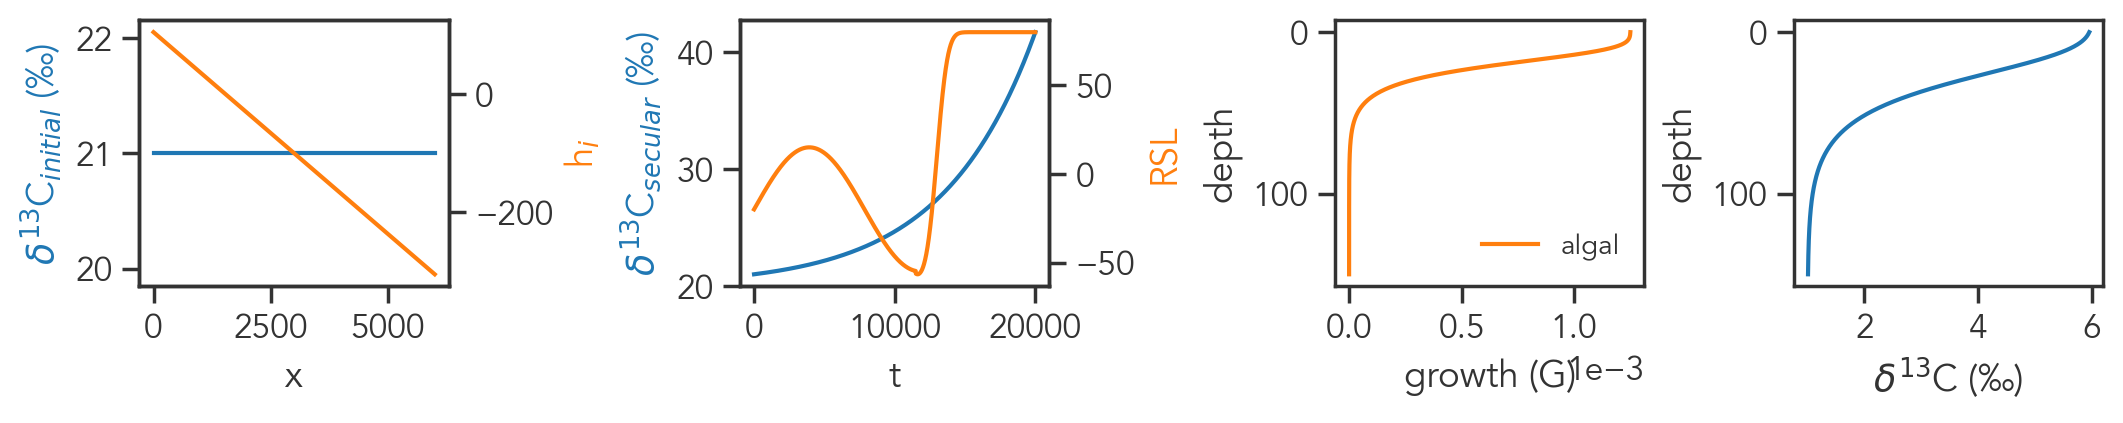

In [3]:
# from the current method
params_c = {'Nx':400,        # was 200; 400
          'xmin':0,
          'xmax':6000,     # was 180, scaled up, just need to change slope of hi
          'dx':0.8, #'none',     # 0.1 # if none defaults to (xmax-xmin)/(Nx); 0.8
          'start':0,
          'dt':0.1,
          'total_n':2000,
          'compiled_steps':100,
          'pel_epsilon':0,   # ‰; 1.5
          'alg_epsilon':0,
          'coral_epsilon':0,
          'ocean_depth':0,  # depth at which seawater reflects open ocean
          'marine_K':2.5e-1,   # 1e-2; 1.5e-1; 2.5e-1, 2.5e-3 dropped by order of mag to test boundary conditions (not diffusing near to bounds)
          'land_K':5e-1,   # 2e-2; 2.5e-1' 5e-1
          'smooth_K':6,      # was 10; the lower it is the more of a sharp step function it is
          'grid_ylen':500,       # 10000; I really don't think it needs to be this big
          'base_depth':10,       # bottom n meters averaged for reaction-curve lower bound (matches shuram_TOC_public convention)
          'A':0.1}             # 0.01 0.1, I think needs to be smaller to scale with small magnitude of this run's topography changes
                # build time and space constraints for initial condition setting and initiation functions (sl, growth, etc.)

x,t,end = init_vars(params_c)
             # A needs to be tuned. If A too big or too small, model provides unrealistic or incorrect functionality

z = np.linspace(1e-5,150,1000)
G_base = 1 # minumum (deep) value; 1
Gm = 5    # maximum (shallow) value; 5
depth_w_fun = lambda x: bosscher_G(x,out='growth',Gm=Gm,G_base=G_base,k=0.05,Ik=750) # can change k for how sharp the gradient is (lower = more gradual); 0.2. 0.4
#depth_w_fun = lambda x: -x/25+6 # simple linear
#depth_w_fun = lambda x: jnp.ones_like(x) * 5  # constant isotopic value
maxw = max(depth_w_fun(z))
minw = min(depth_w_fun(z))

# secular w array
sec_w_funa = lambda t: jnp.zeros_like(t)
sec_w_fun = lambda t: jnp.exp(t/6500)+20
sec_w_i = sec_w_fun(t)[0]

## Define h: initial topographic composition
hi = -0.0685*x+105 # for xmax of 6000; slope chosen to match bahamas aspect ratio

## Define w: initial proxy composition
rsl = 21 #max(hi)
depth = rsl - hi
#wi = depth_w_fun(depth)
#wi = wi.at[:82].set(maxw)
wi = jnp.ones_like(hi) * sec_w_i # shallow value boundary condition for positive run
#wi = jnp.ones_like(hi) * maxw 
#wi = jnp.ones_like(hi) * 0
#wi = wi.at[0].set(maxw)
#wi = wi.at[-1].set(minw)


#wi = wi.at[200:].set(1)
#wi = depth_w_fun(sl_fun(0) - hi)

# sea level curve array - want to simulate a range of magnitudes (HICE is inferred to be ~150m)
sl_funa = lambda t: 35*jnp.sin((t)/2500)-20 # simple version # 1400

slta = np.zeros_like(t)
slta[0:375] = 35 # 375
#slta[0:750] = 65
slta[375:1050] = 0 # 750:1050
slta[1050:1300] = -60 # min(sl_funa(t)) # 1300
slta[1300:] = 80 # 130, 150
slta = gaussian_filter(slta,sigma=60) # apply convolution 60, 40
sl_funb = lambda x: jnp.interp(x,jnp.linspace(0,end,slta.size),slta) # interpolate so works with JAX

sl_fun = lambda t: jnp.where(t<=11500,sl_funa(t),sl_funb(t))
#sl_fun = lambda t: 0.005*t-50 # even simpler distinct prograding with lower sea level
#sl_fun = lambda t: jnp.ones_like(t)*21
#sl_fun = lambda t: jnp.ones_like(t)*-50#jnp.max(hi) # for testing

fig,ax = plt.subplots(1,4,figsize=(10.5,2),layout='constrained')

# initial proxy and topography
ax[0].plot(x,wi,label=r'$\delta^{13}$C$_{initial}$ (‰)',color='tab:blue') # showing index not actual units
axi = ax[0].twinx()
axi.plot(x,hi,label='h$_i$',color='tab:orange') # showing index not actual units
ax[0].set_xlabel('x')
ax[0].set_ylabel(r'$\delta^{13}$C$_{initial}$ (‰)',color='tab:blue')
axi.set_ylabel('h$_i$',color='tab:orange')

# proxy over time
ax[1].plot(t,sec_w_fun(t),color='tab:blue')
ax[1].set_ylabel(r'$\delta^{13}$C$_{secular}$ (‰)',color='tab:blue')
ax[1].set_xlabel('t');
axii = ax[1].twinx()
# sea level
axii.plot(t,sl_fun(t),color='tab:orange')
axii.set_ylabel('RSL',color='tab:orange')

## Growth Functions ##
algal_growth = lambda x: bosscher_G(x,Gm=0.00125,out='growth',Dt=0)

# pelagic growth
ax[2].plot(algal_growth(z),z,color='tab:orange',label='algal',ls='-')
ax[2].set_xlabel('growth (G)')
ax[2].legend(frameon=False)
ax[2].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax[2].set_ylabel('depth')
ax[2].invert_yaxis()

ax[3].plot(depth_w_fun(z),z)
ax[3].invert_yaxis()
ax[3].set_xlabel(r'$\delta^{13}$C (‰)')
ax[3].set_ylabel('depth')
#ax[3].set_xticks(np.arange(G_base,Gm+2));
print('gradient difference = ',max(depth_w_fun(z))-min(depth_w_fun(z)))
print(f'max = {max(depth_w_fun(z)):.2f}; min = {min(depth_w_fun(z)):.2f}')

## Version with no gradient

calculated ymin,ymax = -386.00, 185.00
mean grid dy = 1.144e+00


running model: mass_balance_depthgrads_A0.1_ylen500_2025-04-02 13:09:   0%|          | 0/2000 [00:00<?, ? comp…

plotting results:   0%|          | 0/2000 [00:00<?, ? beds/s]

actual ymin,ymax = -306.00, 105.00


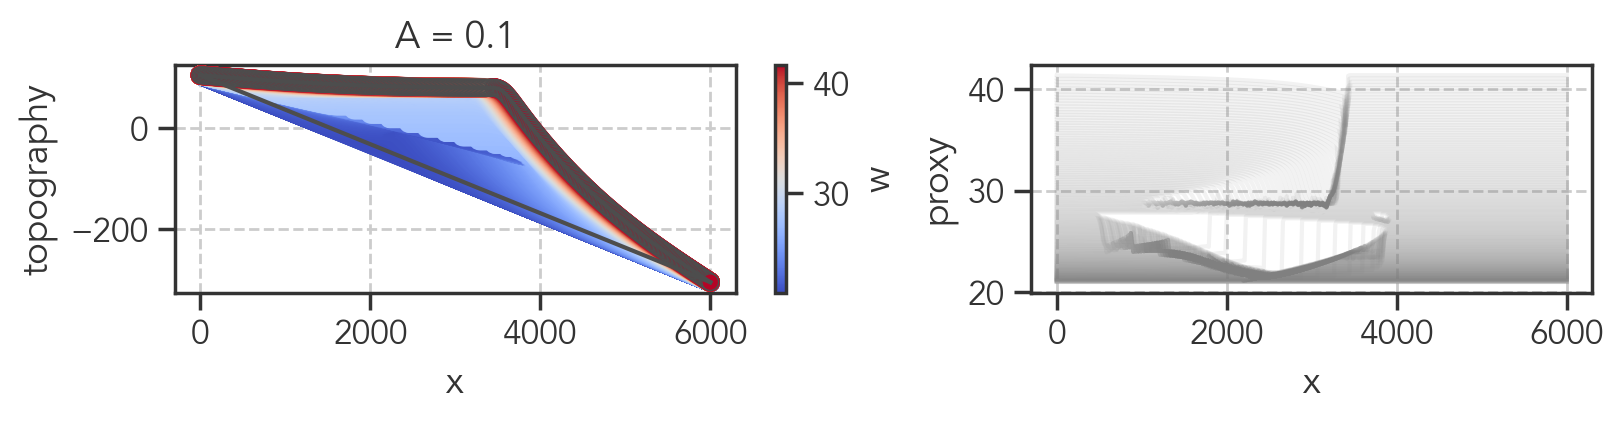

In [4]:
# name of model
desc = 'mass_balance_depthgrads' 

params_c['alg_coef'] = 8.5  # moved from run() kwarg -- alg_coef belongs in params, not run()

mod_c = run(params_c,                            
          model_desc = desc,                
          hi = hi,                            
          wi = wi,                            
          sl_fun = sl_fun,                   
          sec_w_fun = sec_w_fun,           
          wi_sec = True,
          depth_w_fun = None,#depth_w_fun,         
          growth_fun_alg = algal_growth,     
          plot_skip = 10,                    
          plot_out = True,
          const_K = False,                   
          w_set_erode = True,              
          full_storage = False,              
          figsize = (8,2),
          no_res_bounds = False,
          normalize_balance = True)

max depth = 411.00


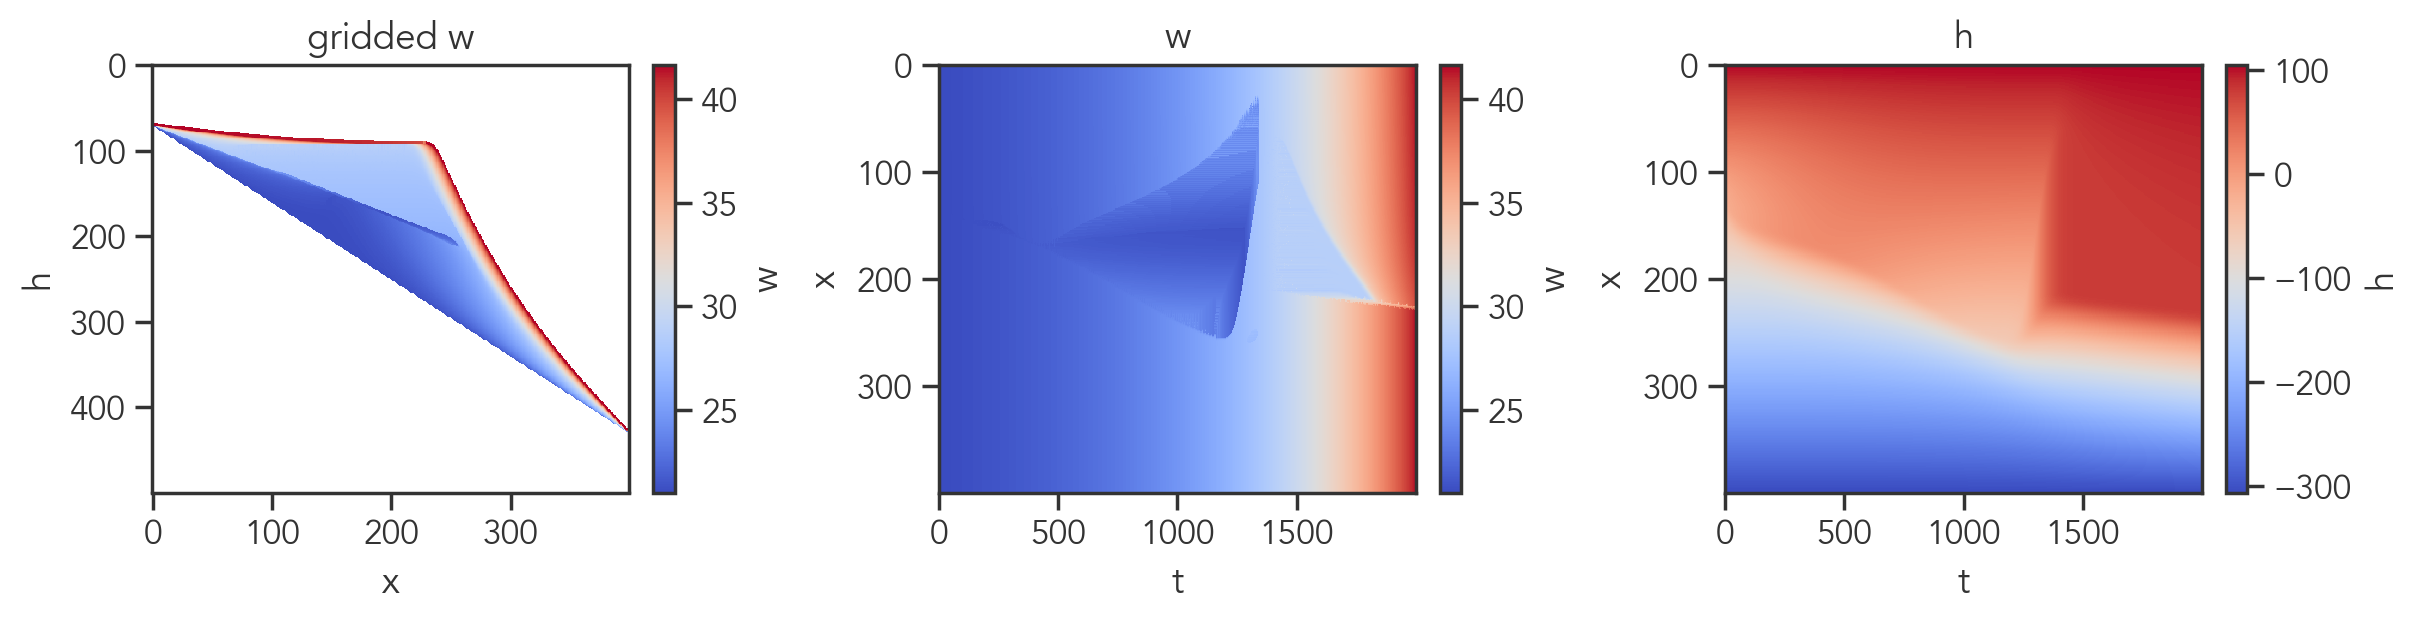

In [5]:
# define max depthD
max_depth = np.nanmax(mod_c['ds'])
print(f'max depth = {max_depth:.2f}')

# simple version with fewer facies and just depth ranges
facies_data = facies(max_depth)

# facies colours # my_pal
facies_colours = list(sns.color_palette('BrBG',n_colors=len(facies_data)+1).as_hex()) # add one as going to drop the white one
facies_colours.pop(5) # drop the white one # was 4
#facies_colours[0] = '#C2461F'
sns.color_palette(facies_colours) # look at the palette

## model outputs|
out_c = Model_output(**mod_c,facies_data=facies_data,facies_colours=facies_colours,bc_filter=False,set_under_c='.3',im_ylen=5000,images=True)
out_c.plot_grids()

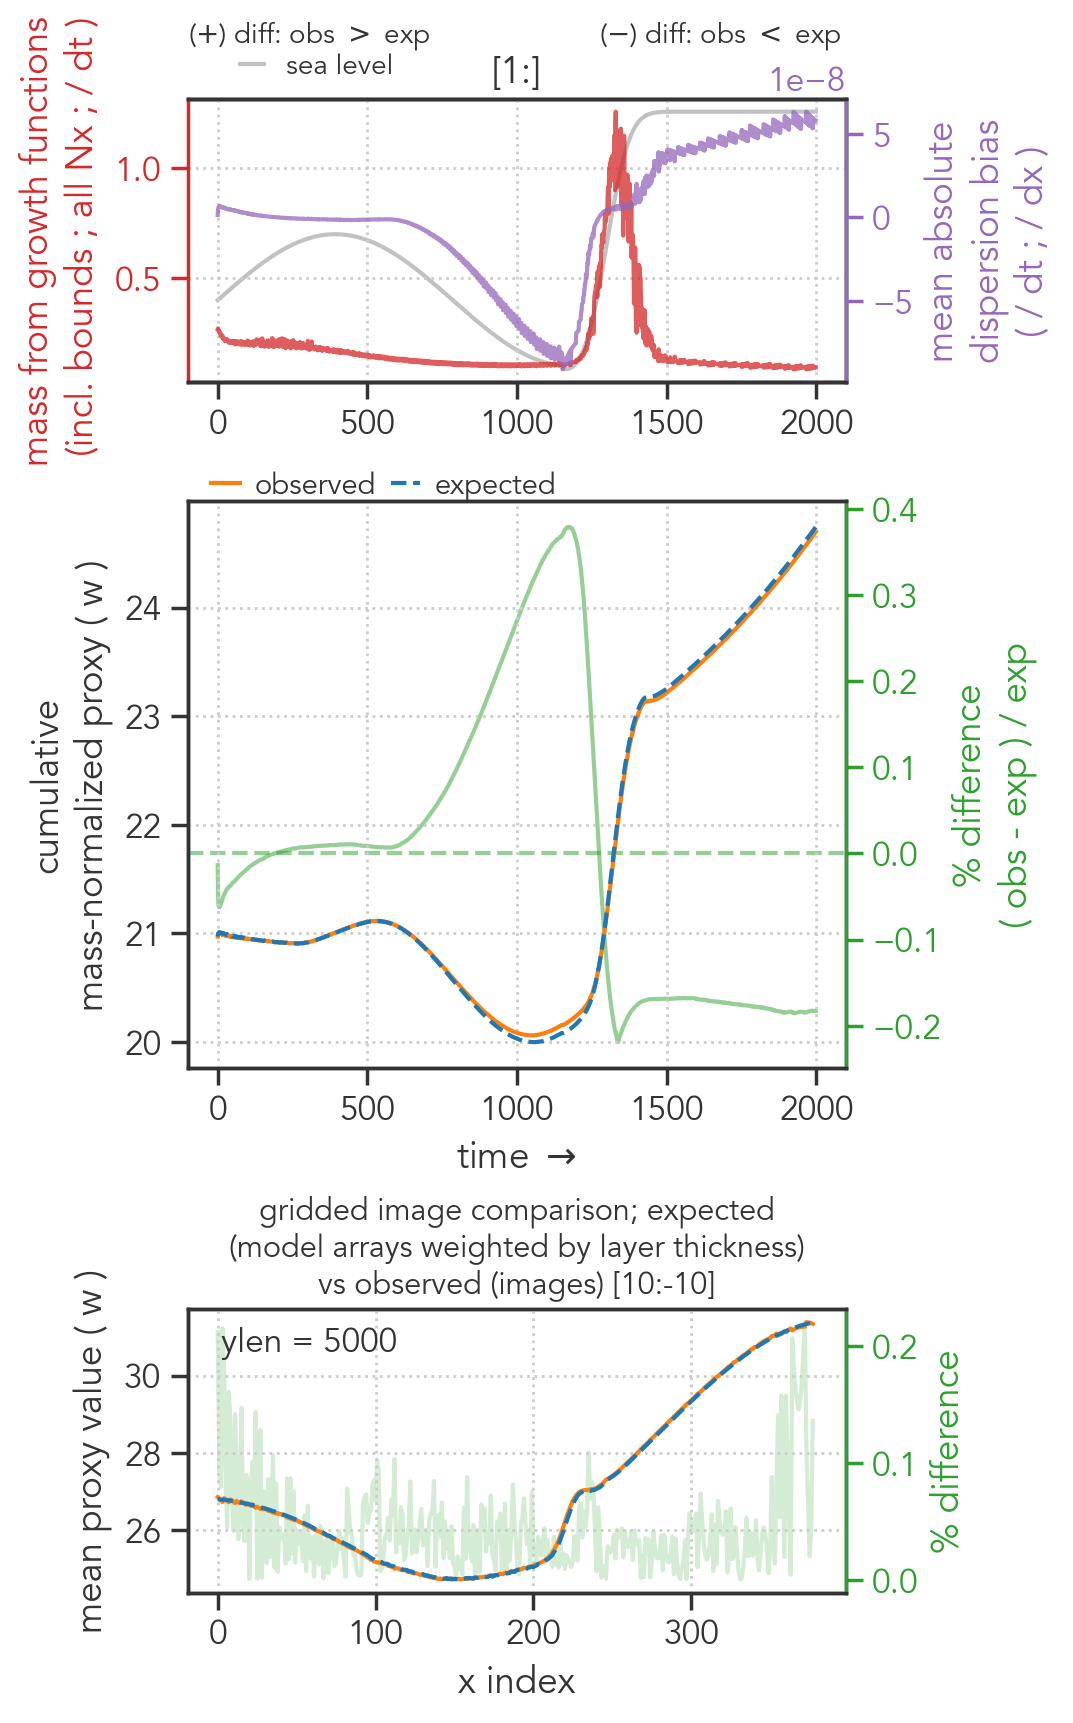

In [6]:
fig,ax,diffw = out_c.mass_balance(out=True,show='proxy',percent=True,rsl=True,im_l_lim=10,im_r_lim=-10)
# #fig.savefig(sem_dir+'mass.png',format='png',dpi=300,bbox_inches='tight',transparent=True)

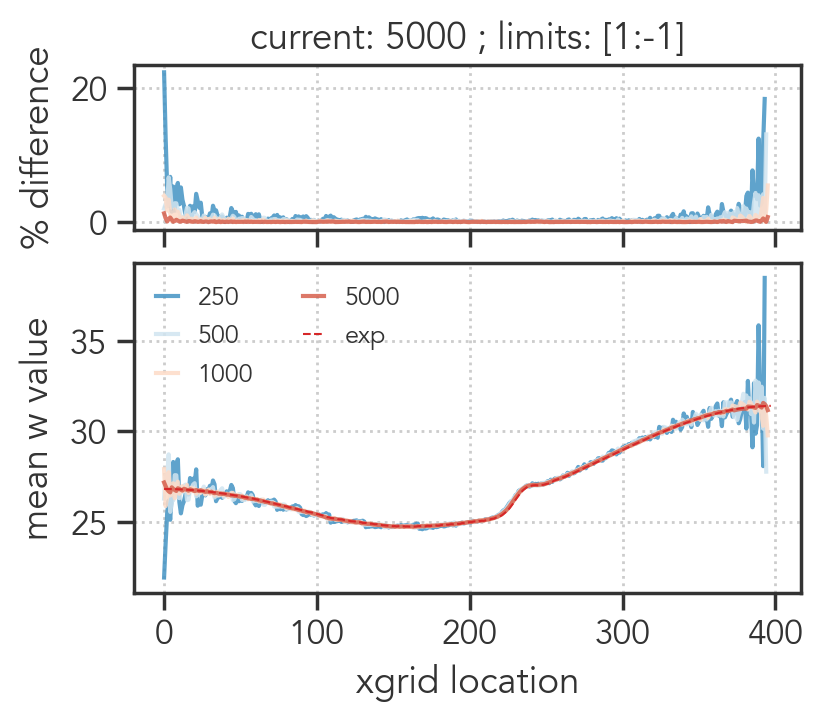

In [7]:
ylens = [250,500,1000,5000]
fig,md,mb,rd,ims = out_c.im_res_compare(ylens,pal='RdBu_r',ncols='multi',im_l_lim=1,im_r_lim=-1,mean_diff_out=True)

# # save figure
# #fig.savefig(tex_fig_dir+'ylen_test.pdf',format='pdf',bbox_inches='tight',transparent=False)

## Version with gradient

In [8]:
mg = max(depth_w_fun(z))
wig = np.ones_like(x)*mg
wig[0]

Array(5.9519525, dtype=float32)

calculated ymin,ymax = -386.00, 185.00
mean grid dy = 1.144e+00


running model: mass_balance_depthgrads_A0.1_ylen500_2025-04-02 13:12:   0%|          | 0/2000 [00:00<?, ? comp…

plotting results:   0%|          | 0/2000 [00:00<?, ? beds/s]

actual ymin,ymax = -306.00, 105.00


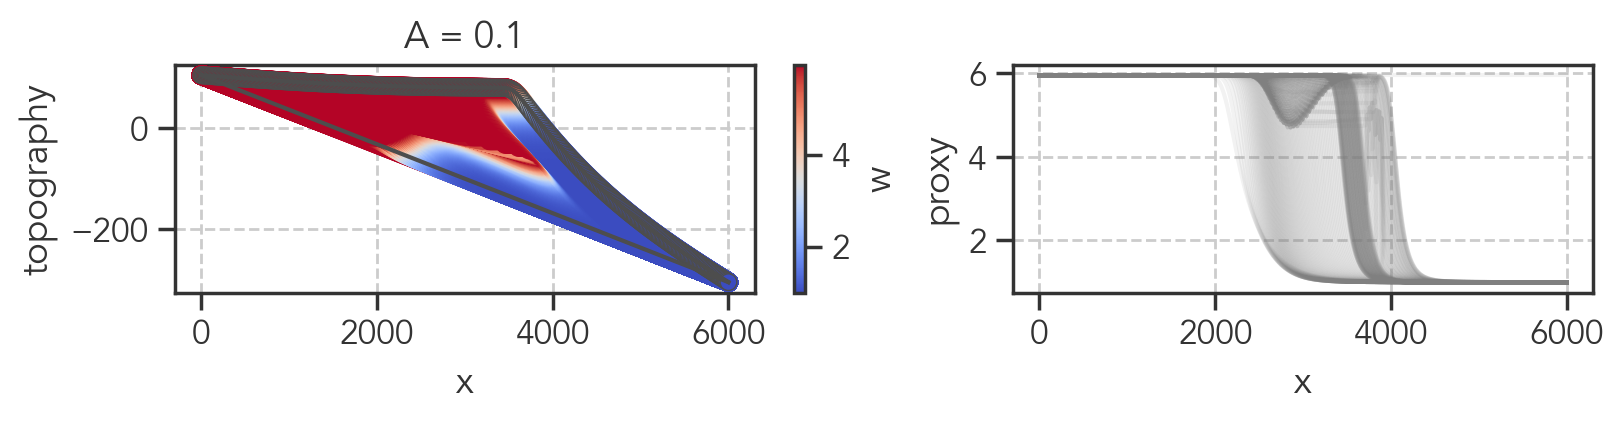

In [9]:
# name of model
desc = 'mass_balance_depthgrads' 

params_c['alg_coef'] = 8.5  # moved from run() kwarg -- alg_coef belongs in params, not run()

mod_d = run(params_c,                            
          model_desc = desc,                
          hi = hi,                            
          wi = wig,                            
          sl_fun = sl_fun,                   
          sec_w_fun = sec_w_funa,           
          wi_sec = False,
          depth_w_fun = depth_w_fun,         
          growth_fun_alg = algal_growth,     
          plot_skip = 10,                    
          plot_out = True,
          const_K = False,                   
          w_set_erode = True,              
          full_storage = False,              
          figsize = (8,2),
          no_res_bounds = False,
          normalize_balance = True)

max depth = 411.00


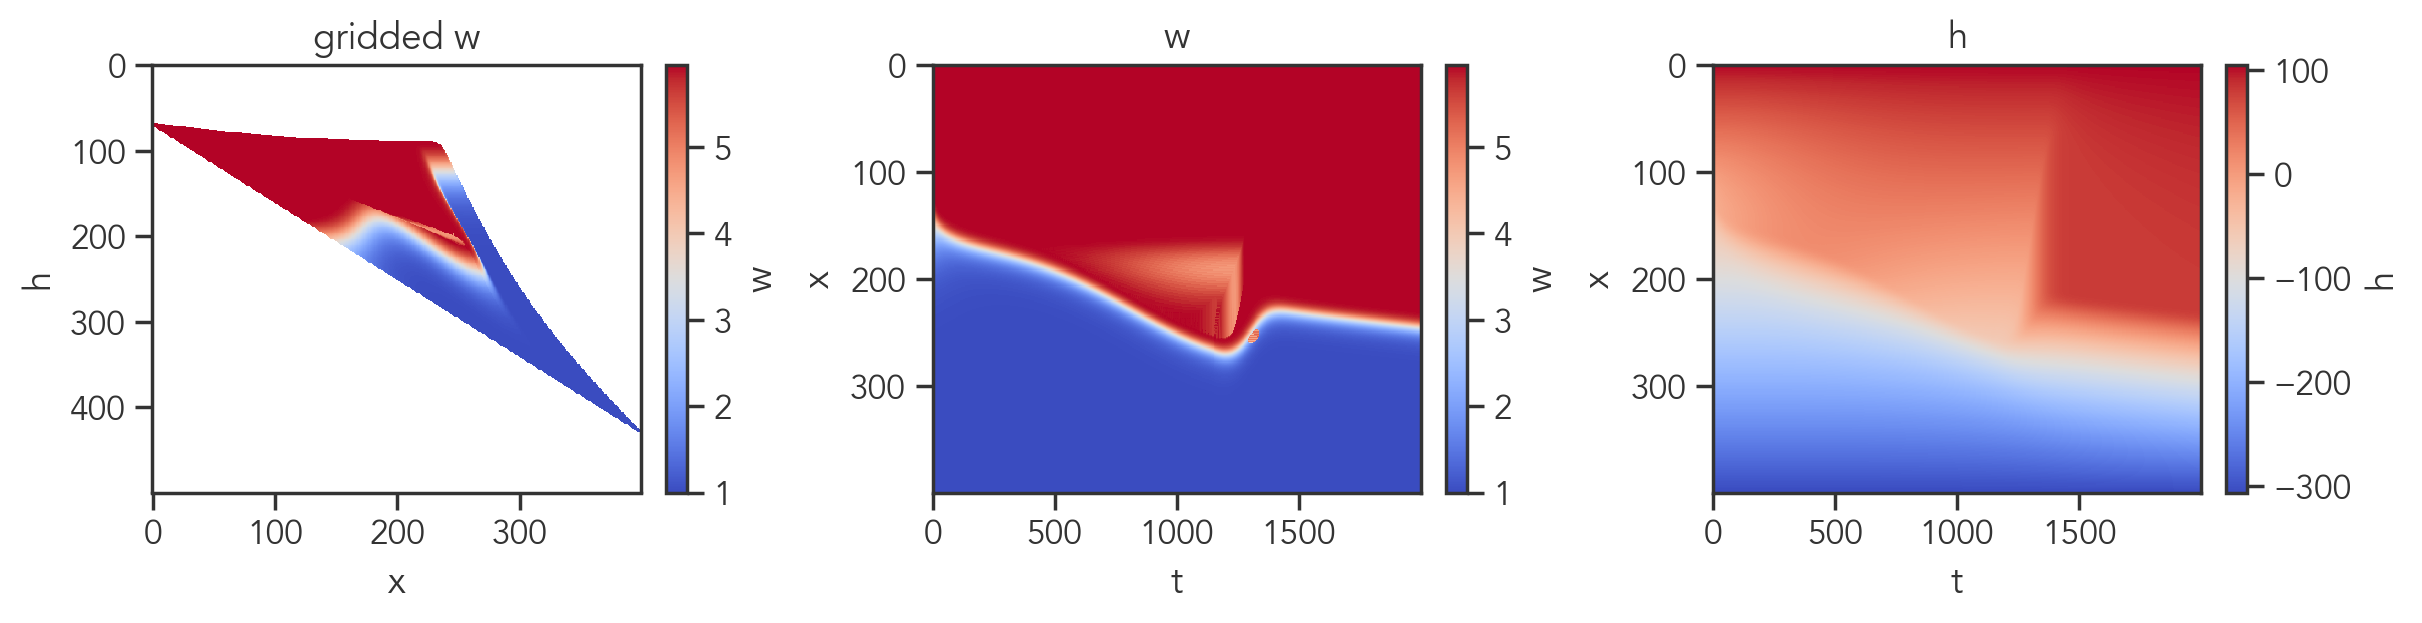

In [10]:
# define max depthD
max_depth = np.nanmax(mod_d['ds'])
print(f'max depth = {max_depth:.2f}')

# simple version with fewer facies and just depth ranges
facies_data = facies(max_depth)

## model outputs|
out_d = Model_output(**mod_d,facies_data=facies_data,facies_colours=facies_colours,bc_filter=False,set_under_c='.3',im_ylen=5000,images=True)
out_d.plot_grids()

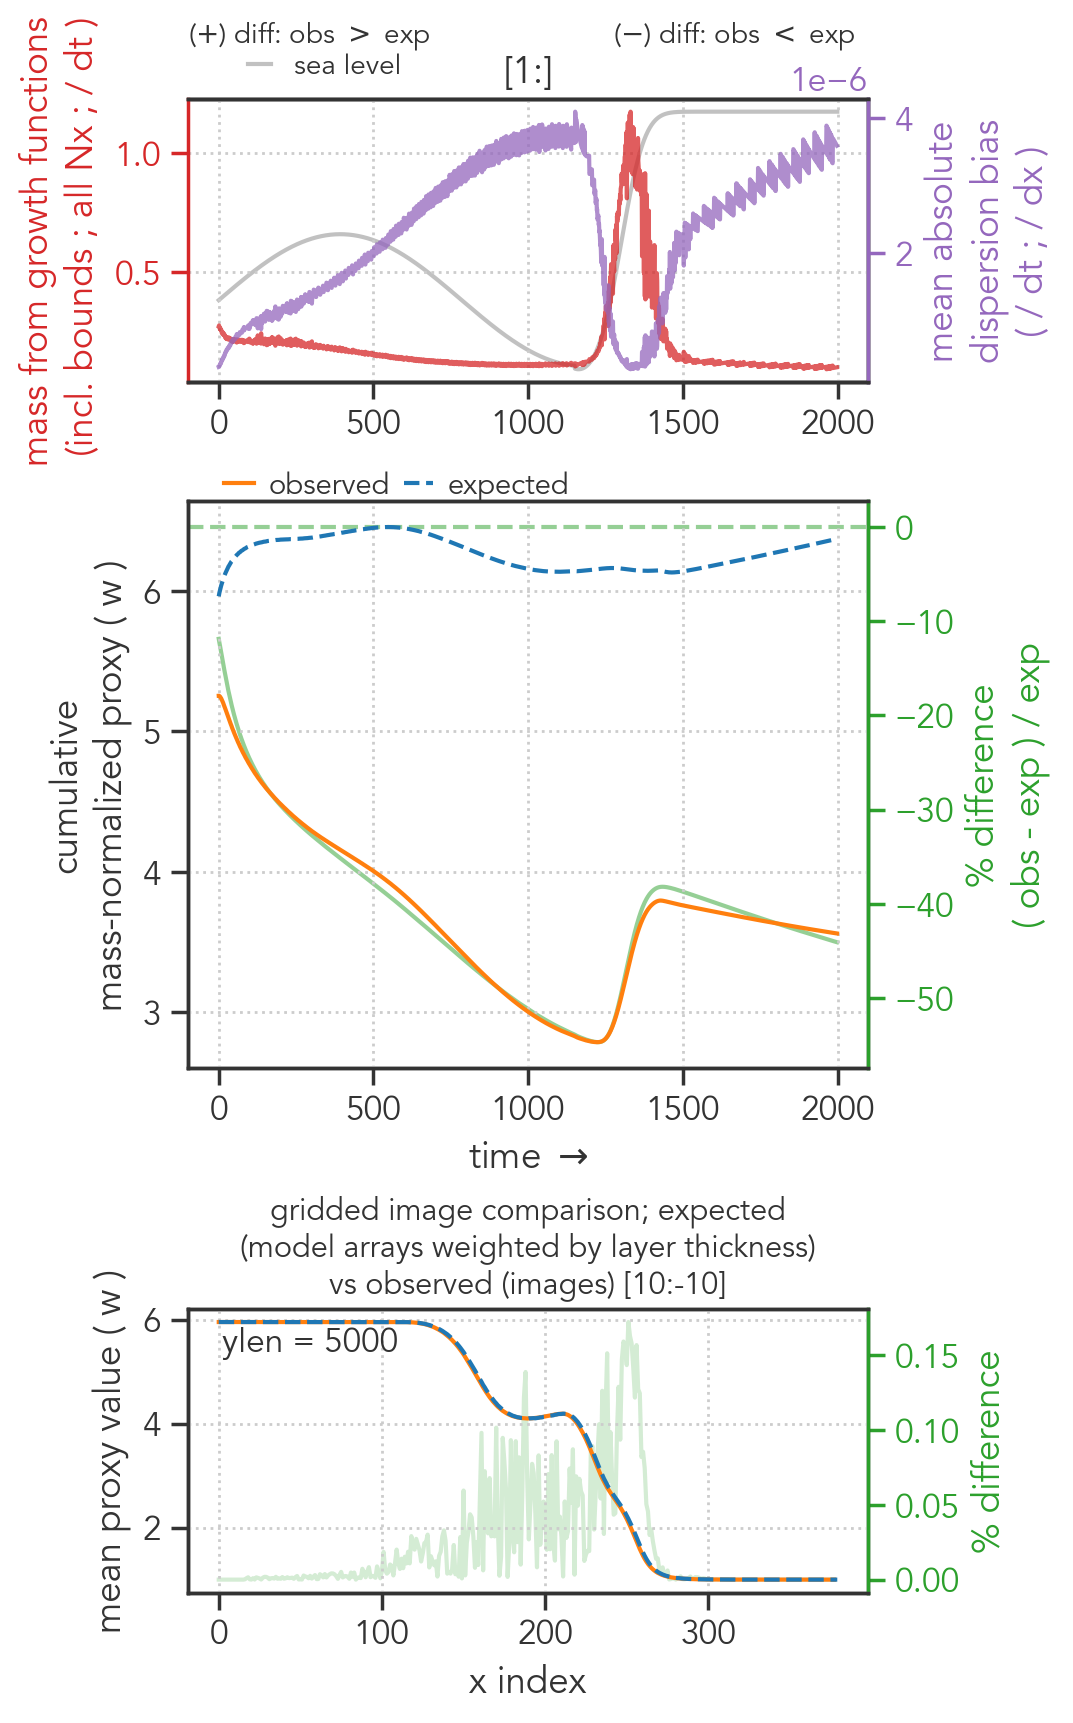

In [11]:
fig,ax,diffw = out_d.mass_balance(out=True,show='proxy',percent=True,rsl=True,im_l_lim=10,im_r_lim=-10)
# #fig.savefig(sem_dir+'mass.png',format='png',dpi=300,bbox_inches='tight',transparent=True)

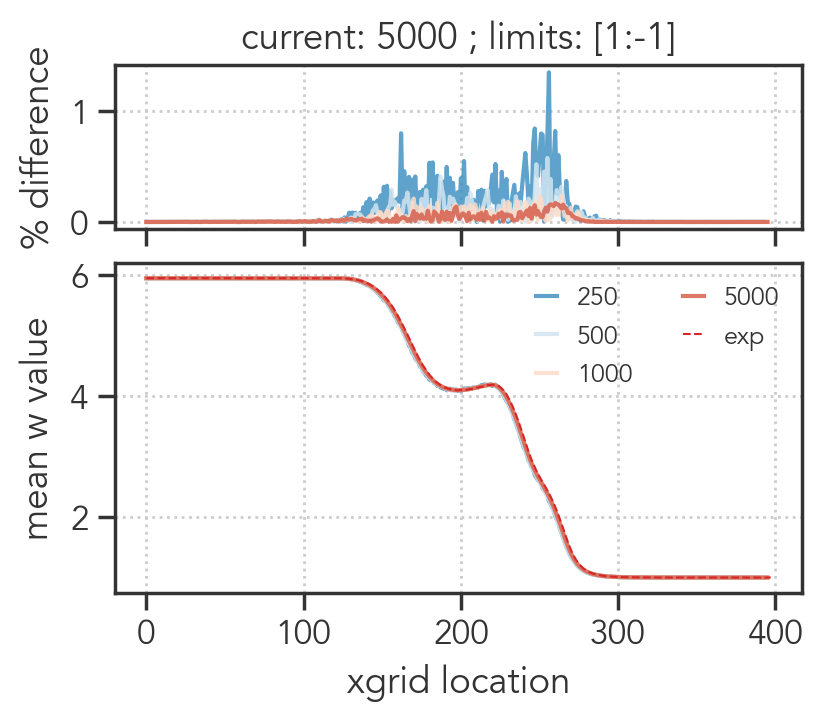

In [12]:
fig,md,mb,rdg,ims = out_d.im_res_compare(ylens,pal='RdBu_r',ncols='multi',im_l_lim=1,im_r_lim=-1,mean_diff_out=True)

# # save figure
# #fig.savefig(tex_fig_dir+'ylen_test.pdf',format='pdf',bbox_inches='tight',transparent=False)

## Version with gradient (direction flipped)

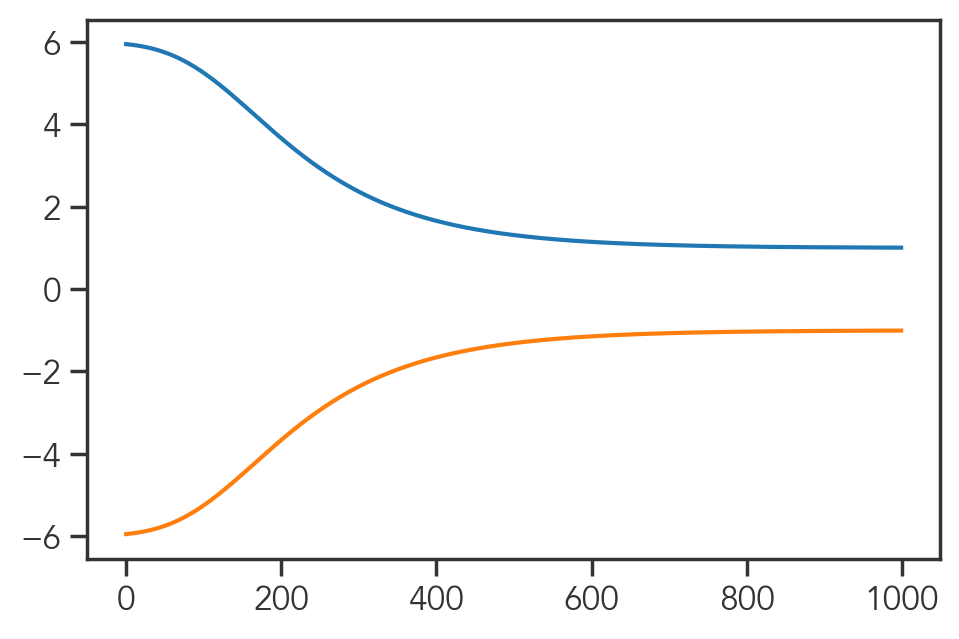

In [13]:
depth_w_funr = lambda x: bosscher_G(x,out='growth',Gm=-5,G_base=-1,k=0.05,Ik=750)

plt.plot(depth_w_fun(z))
plt.plot(depth_w_funr(z))

In [14]:
mg2 = min(depth_w_funr(z))
wig2 = np.ones_like(x)*mg2
wig2[0]

Array(-5.9519525, dtype=float32)

calculated ymin,ymax = -386.00, 185.00
mean grid dy = 1.144e+00


running model: mass_balance_depthgrads_A0.1_ylen500_2025-04-02 13:15:   0%|          | 0/2000 [00:00<?, ? comp…

plotting results:   0%|          | 0/2000 [00:00<?, ? beds/s]

actual ymin,ymax = -306.00, 105.00


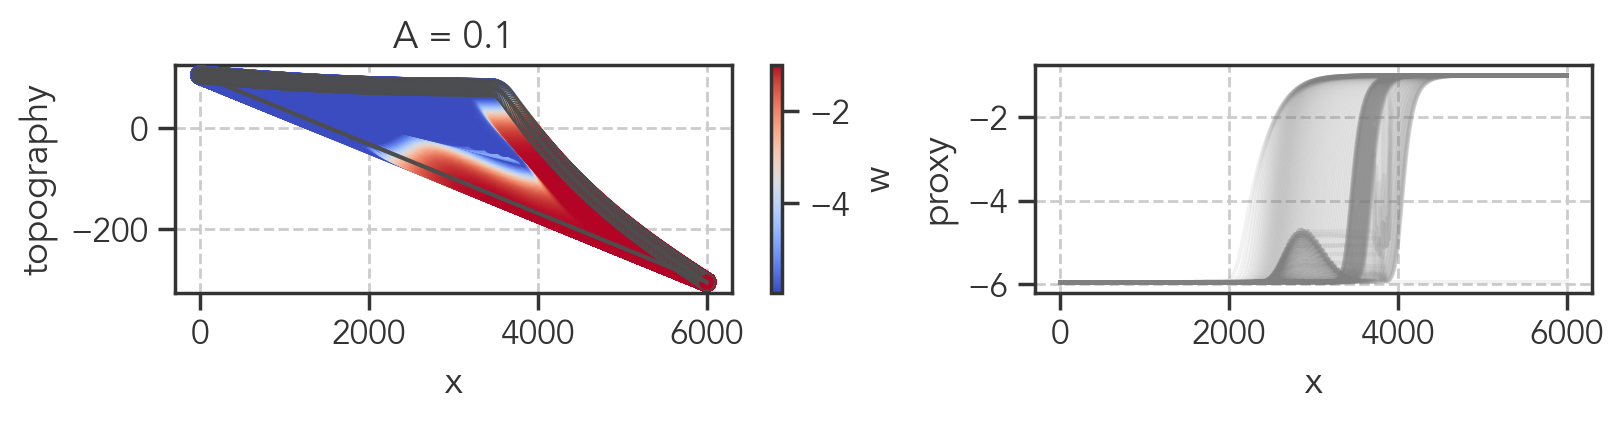

In [15]:
# name of model
desc = 'mass_balance_depthgrads' 

params_c['alg_coef'] = 8.5  # moved from run() kwarg -- alg_coef belongs in params, not run()

mod_r = run(params_c,                            
          model_desc = desc,                
          hi = hi,                            
          wi = wig2,                            
          sl_fun = sl_fun,                   
          sec_w_fun = sec_w_funa,           
          wi_sec = False,
          depth_w_fun = depth_w_funr,         
          growth_fun_alg = algal_growth,     
          plot_skip = 10,                    
          plot_out = True,
          const_K = False,                   
          w_set_erode = True,              
          full_storage = False,              
          figsize = (8,2),
          no_res_bounds = False,
          normalize_balance = True)

max depth = 411.00


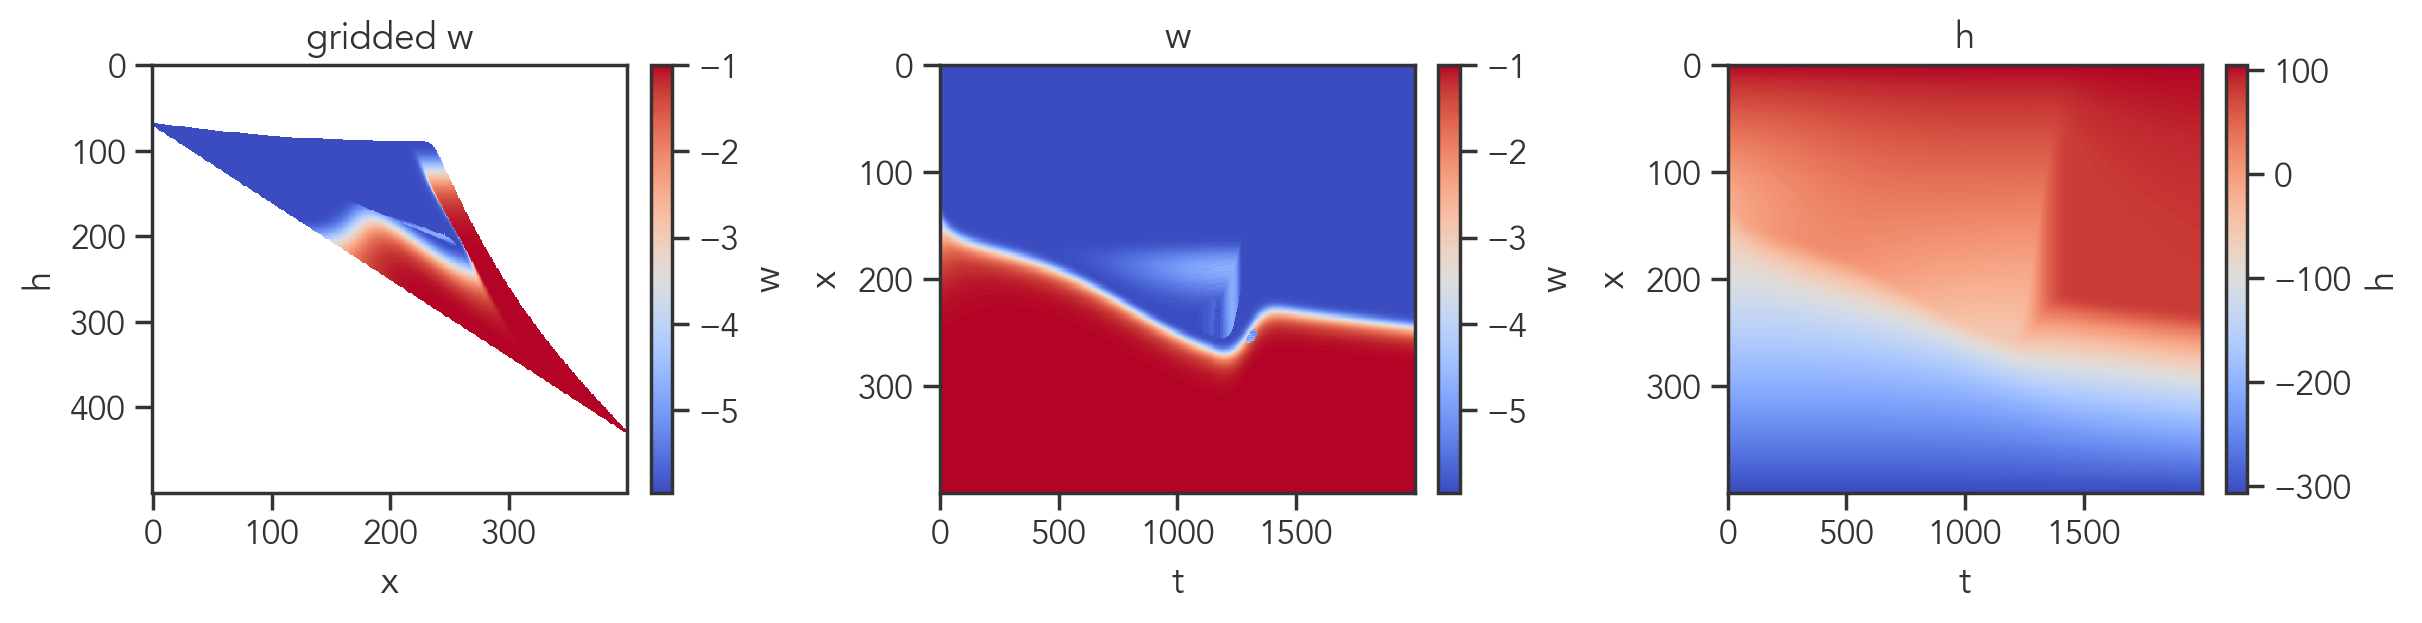

In [16]:
# define max depthD
max_depth = np.nanmax(mod_d['ds'])
print(f'max depth = {max_depth:.2f}')

# simple version with fewer facies and just depth ranges
facies_data = facies(max_depth)

## model outputs|
out_r = Model_output(**mod_r,facies_data=facies_data,facies_colours=facies_colours,bc_filter=False,set_under_c='.3',im_ylen=5000,images=True)
out_r.plot_grids()

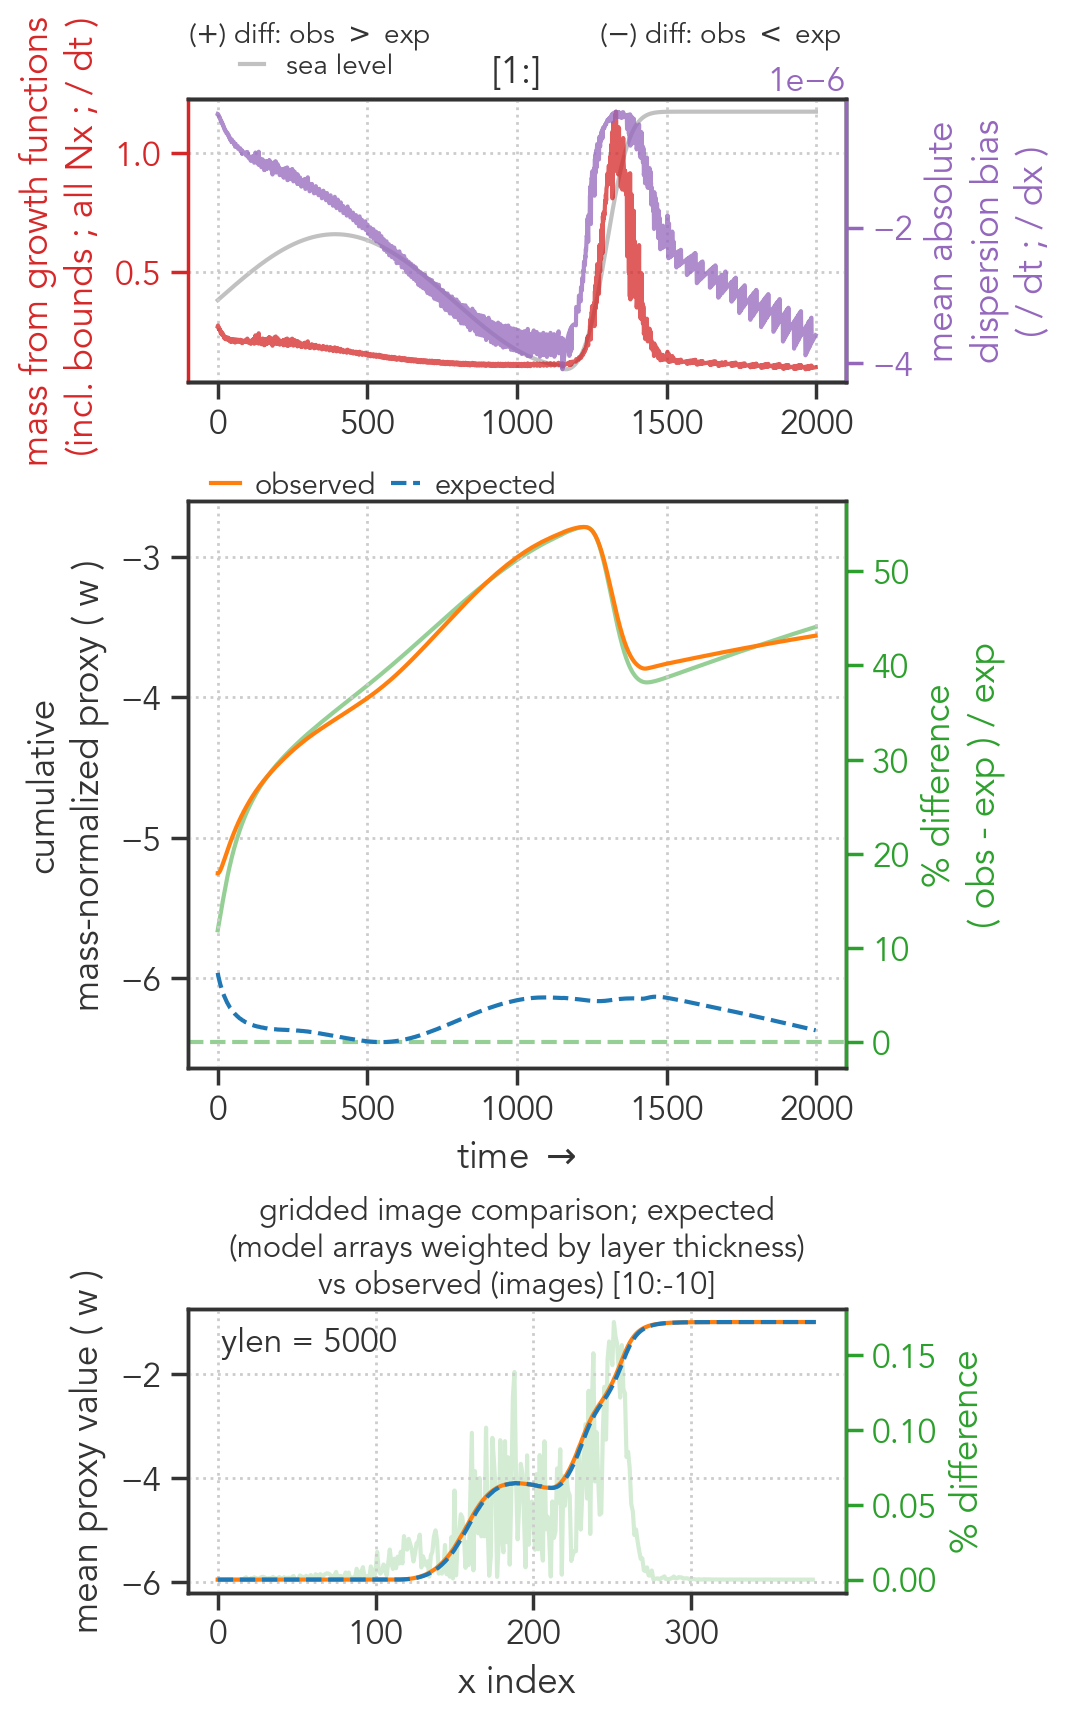

In [17]:
fig,ax,diffw = out_r.mass_balance(out=True,show='proxy',percent=True,rsl=True,im_l_lim=10,im_r_lim=-10)
# #fig.savefig(sem_dir+'mass.png',format='png',dpi=300,bbox_inches='tight',transparent=True)

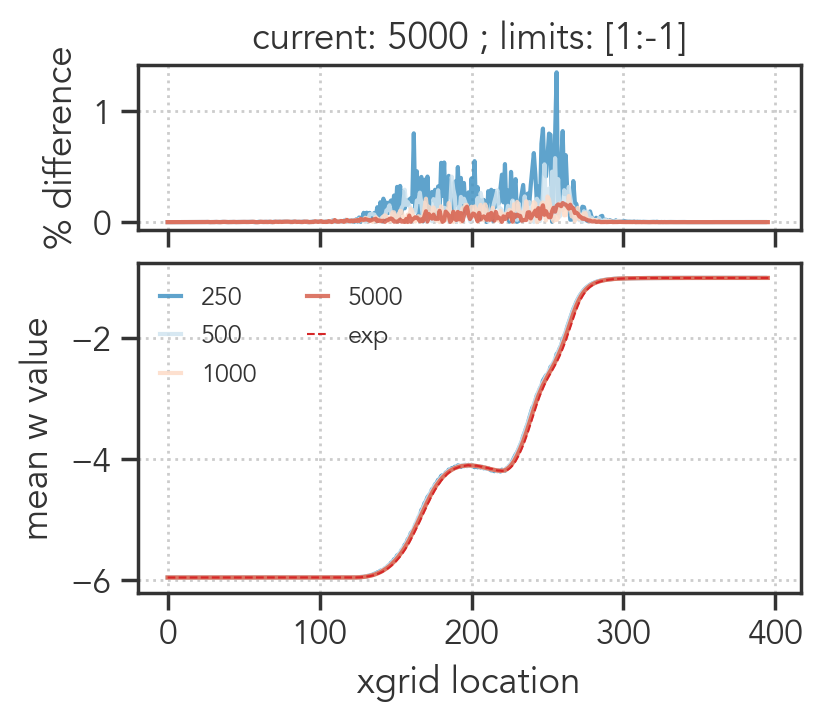

In [18]:
fig,md,mb,rdr,ims = out_r.im_res_compare(ylens,pal='RdBu_r',ncols='multi',im_l_lim=1,im_r_lim=-1,mean_diff_out=True)

# # save figure
# #fig.savefig(tex_fig_dir+'ylen_test.pdf',format='pdf',bbox_inches='tight',transparent=False)

## Figure for supplement

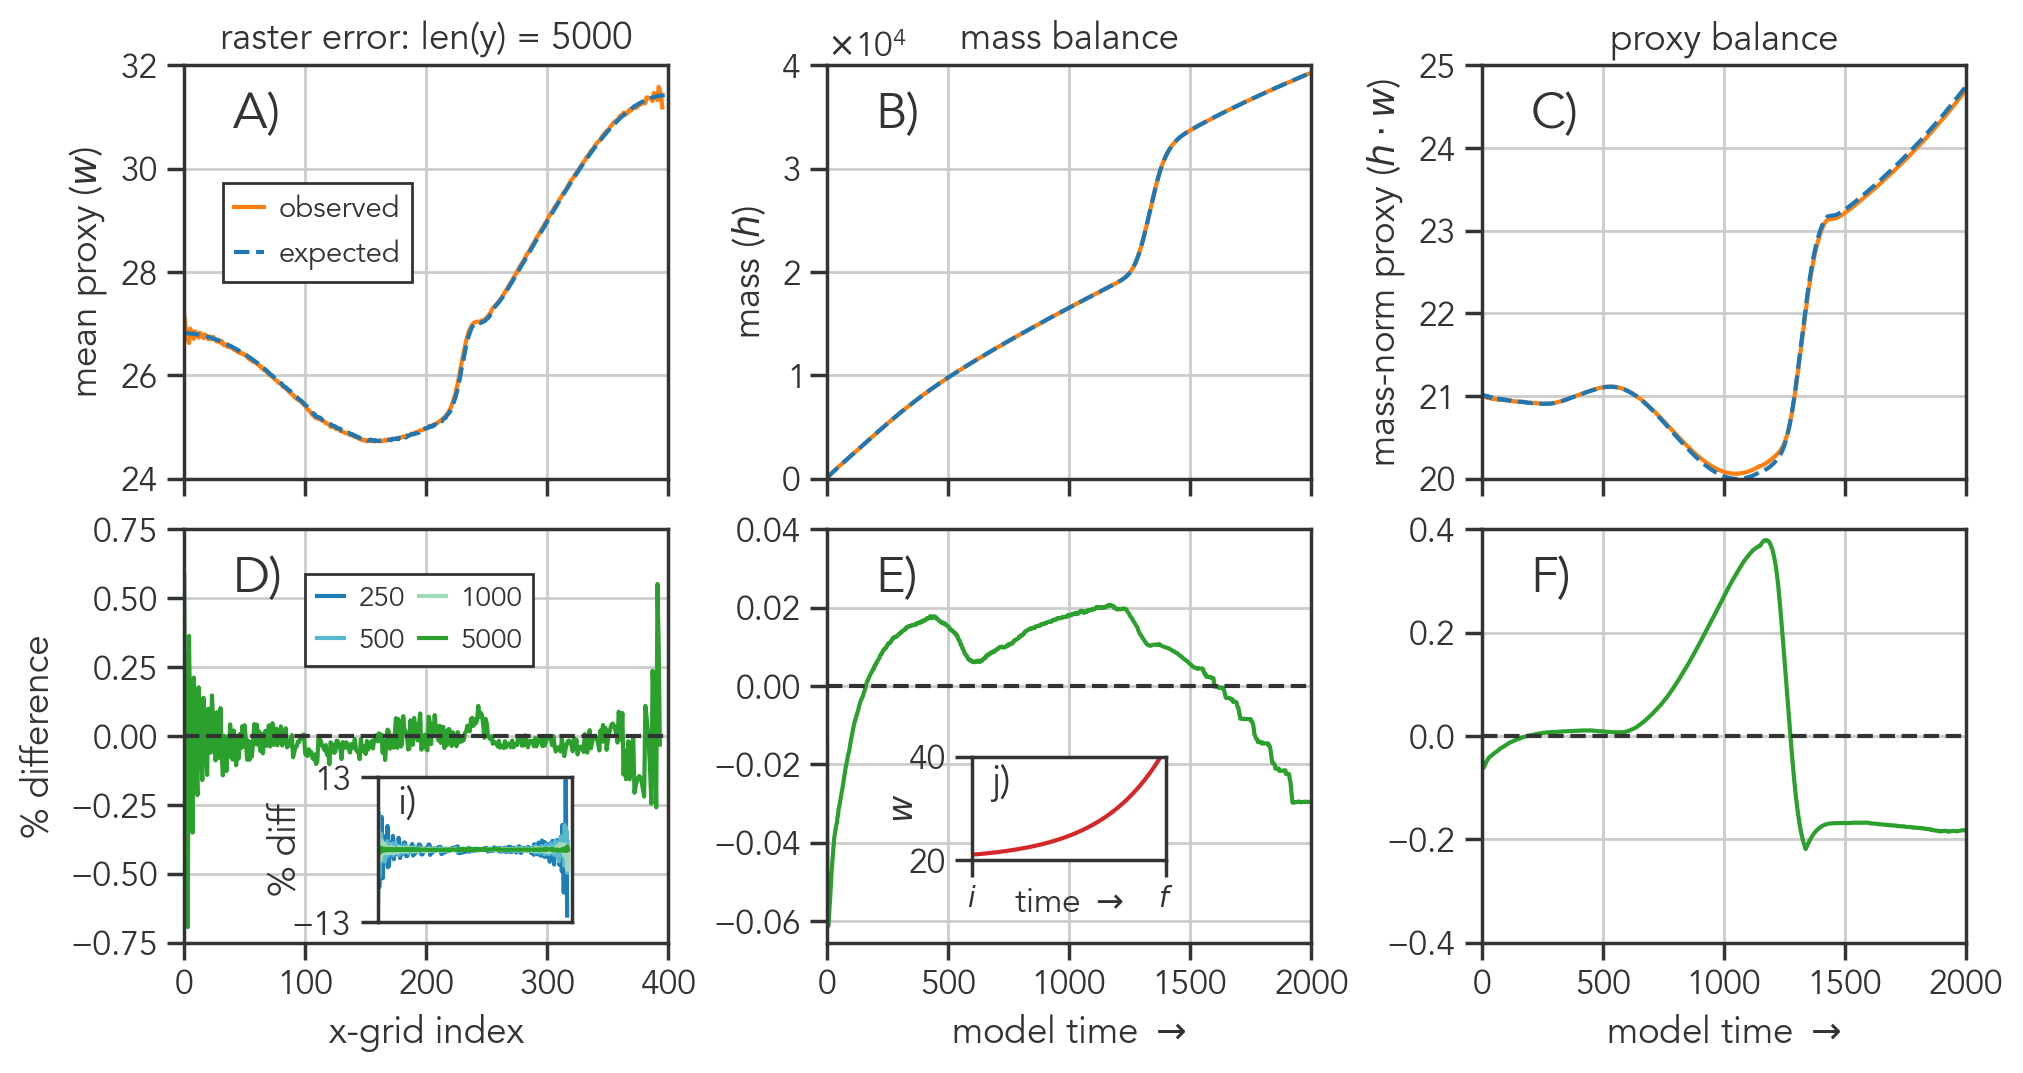

In [27]:
## want to plot mass normalized balance, percent difference, image balance, and image percent difference (4 metrics)

# image error
edge = 1 # 10
mean_obs, weighted_mean_exp, rel_diff, rel_diff_noabs, abs_diff, raw_diff = out_c.image_diff(im_l_lim=edge,im_r_lim=-edge)

# image difference percent; manually doing it so not abs
rel_diffa = (raw_diff / np.abs(mean_obs)) * 100  # relative difference in percentage
rel_diffa = rel_diffa[edge:-edge]

# mass balance
obs = out_c.wobs[1:] # skip first index as start is 0
exp = out_c.wexp[1:]

# mass balance; mass only
obsm = out_c.mobs[1:] # skip first index as start is 0
expm = out_c.mexp[1:]

# difference mass balance
# percent
diff = ((obs - exp) / np.abs(exp)) * 100 # with absolute
diffm = ((obsm - expm) / np.abs(expm)) * 100 # with absolute

# plot
fig, ax = plt.subplots(2, 3, figsize=(10, 5.25), layout='constrained', sharex='col')
axs = ax.ravel()

# label abc and format
al = string.ascii_uppercase[:len(axs)]
for a, l in zip(axs, al):
    a.text(0.1, 0.85, f'{l})', transform=a.transAxes, fontsize=18)
    a.grid(ls='-')

axs[4].set_xlabel(r'model time $\rightarrow$')
axs[5].set_xlabel(r'model time $\rightarrow$')
axs[0].set_title(f'raster error: len(y) = {out_c.im_ylen}')
axs[2].set_title('proxy balance')
axs[1].set_title('mass balance')

# plot image error (col 1, row 1)
axs[0].plot(mean_obs, label='observed', color='tab:orange')
axs[0].plot(weighted_mean_exp, label='expected', linestyle='--', color='tab:blue')
axs[3].set_xlabel('x-grid index')
axs[0].set_ylabel('mean proxy ($w$)')
axs[0].legend(frameon=True, handlelength=1, columnspacing=0.5, handletextpad=0.5,
              fontsize=10.5, bbox_to_anchor=(0.5, 0.75))

# plot percent image error (col 1, row 2)
axs[3].axhline(0, ls='--', color='.2', zorder=3)
axs[3].plot(rel_diffa, color='tab:green', zorder=2)
axs[3].set_ylabel('% difference')

# plot mass only balance
axs[1].plot(obsm, ls='-', color='tab:orange', label='observed')
axs[1].plot(expm, ls='--', color='tab:blue', label='expected')
axs[1].set_ylabel('mass ($h$)')
axs[1].yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
axs[1].ticklabel_format(axis='y', style='sci', scilimits=(0, 0))# plot mass only balance

# plot mass only percent difference
axs[4].axhline(0, ls='--', color='.2', zorder=3)
axs[4].plot(np.arange(len(diffm)), diffm, ls='-', color='tab:green', zorder=2)
axs[4].set_ylim(top=0.04)

# plot cumulative proxy mass balance (col 3, row 1)
axs[2].plot(obs, ls='-', color='tab:orange', label='observed')
axs[2].plot(exp, ls='--', color='tab:blue', label='expected')
axs[2].set_ylabel(r'mass-norm proxy ($h \cdot w$)')

# plot cumulative proxy mass balance diff (col 3, row 2)
axs[5].axhline(0, ls='--', color='.2', zorder=3)
axs[5].plot(np.arange(len(diff)), diff, ls='-', color='tab:green', zorder=2)
#axs[5].set_ylabel('% difference')
# axs[5].yaxis.tick_right()
# axs[5].yaxis.set_label_position('right')

# add insets to show sea level and secular change to dic
axj = axs[4].inset_axes([0.3,0.2,0.4,0.25])
axj.plot(out_c.w_strat_t,color='tab:red')
axj.set_ylim(20,40)
axj.set_xlim(0,2000)
axj.set_xticks([0,2000],['$i$','$f$'],fontsize=10)
axj.set_xlabel(r'time $\rightarrow$',fontsize=12,labelpad=-10)
axj.set_ylabel('$w$',fontsize=12,labelpad=-5)
axj.text(0.1, 0.65, 'j)', transform=axj.transAxes, fontsize=14)

# inset for image sensitivity
axi = axs[3].inset_axes([0.4,0.05,0.4,0.35])
a = sns.color_palette('GnBu_r',n_colors=len(ylens)).as_hex()
a[-1] = 'tab:green'
a = sns.color_palette(a)
axi.set_prop_cycle(cycler('color',a))
axi.set_xticks([])
axi.set_ylabel('% diff',labelpad=-5)
for r,yl in zip(rd,ylens):
    axi.plot(r[1:-1],label=yl)
axi.legend(ncols=2,handlelength=1, columnspacing=0.5, handletextpad=0.5,bbox_to_anchor=(0.875,2.5))
axi.text(0.1, 0.75, 'i)', transform=axi.transAxes, fontsize=14)

# clean up lims
axs[3].set_xlim(0,400)
axs[4].set_xlim(0,2000)
axs[5].set_xlim(0,2000)
axs[1].set_ylim(0e4,4e4)
axs[0].set_ylim(24,32)
axs[2].set_ylim(20,25)
axs[5].set_ylim(-0.4,0.4)
axs[3].set_ylim(-0.75,0.75)
axi.set_xlim(0,400)
axi.set_ylim(-13,13)
axi.set_yticks([-13,13])

# save figure
fig.savefig(tex_fig_dir + 'balance.pdf', format='pdf', bbox_inches='tight', transparent=False)

## Plot of bias vs sediment added for dispersive argument

In [20]:
# sk = 0
# # no gradient
# bias = out_c.biastot[sk:]
# massdt = out_c.massdt[sk:]

# # gradient (positive)
# bias_g = out_d.biastot[sk:]
# massdt_g = out_d.massdt[sk:]

# # gradient (negative)
# bias_r = out_r.biastot[sk:]
# massdt_r = out_r.massdt[sk:]

# #fig, ax = plt.subplots(figsize=(4.5,3.75), layout='constrained')
# fig, ax = plt.subplots(figsize=(4.75,3.75), layout='constrained')

# # format
# ax.grid(ls='-')
# ax.set_xlabel(r'model time $\rightarrow$')
# ax.set_xlim(0,2000)

# # plot bias
# gcol = '#f0bcbc' #'#e39695' # sns.color_palette('RdBu').as_hex()[1]
# #ax.plot(bias_g,color=gcol,label='gradient')
# ax.plot(bias,color='tab:red',label='no gradient')
# ax.set_ylim(0e-8,10e-8)
# #ax.set_ylim(1e-11,1e-5)
# ax.set_ylabel(r'mean dispersive bias ($w \cdot t$)',color='tab:red')
# ax.tick_params(axis='y',which='both',colors='tab:red')
# #ax.set_yscale('log')
# #ax.legend(handlelength=1, columnspacing=0.5, handletextpad=0.5,bbox_to_anchor=(0.4,0.6))

# # plot mass per dt
# axa = ax.twinx()
# axa.plot(massdt,color='tab:blue')
# axa.set_ylim(0,1.2)
# #axa.set_ylim(1e-2,1e1)
# axa.tick_params(axis='y', colors='tab:blue')
# #axa.spines['right'].set_color('tab:orange')
# axa.set_ylabel('mass added per timestep ($h/dt$)',color='tab:blue')
# #axa.set_yscale('log')

# # save figure
# fig.savefig(tex_fig_dir + 'disperse.pdf', format='pdf', bbox_inches='tight', transparent=False)

## Bias plot with one axis

In [21]:
sns.color_palette('RdBu')

[(0.7561707035755478, 0.21038062283737025, 0.22352941176470587),
 (0.940715109573241, 0.6099192618223759, 0.4812764321414839),
 (0.9856978085351787, 0.8889657823913879, 0.8320645905420992),
 (0.8605151864667436, 0.9174163783160324, 0.9487120338331411),
 (0.530026912725875, 0.7456362937331797, 0.8560553633217994),
 (0.1843137254901961, 0.47266435986159167, 0.7116493656286044)]

In [22]:
# # changed model to not make bias absolute, but as showing magnitude differences here, will make absolute
# sk = 0

# # no gradient
# bias = out_c.biastot[sk:]
# bias_abs = np.abs(out_c.biastot[sk:])
# massdt = out_c.massdt[sk:]

# # gradient (positive)
# bias_g = out_d.biastot[sk:]
# bias_g_abs = np.abs(out_d.biastot[sk:])
# massdt_g = out_d.massdt[sk:]

# # gradient (negative); not plotting here as when absolute, same as postive one
# bias_r = out_r.biastot[sk:]
# bias_r_abs = np.abs(out_r.biastot[sk:])
# massdt_r = out_r.massdt[sk:]

# fig, ax = plt.subplots(figsize=(3.5,3.15))

# # format
# ax.grid(ls='-')
# ax.set_xlabel(r'model time $\rightarrow$')
# ax.set_xlim(0,2000)

# # plot mass per dt
# ax.plot(massdt,color='tab:blue',label='added mass/dt')
# ax.set_ylim(1e-11,1e1)
# # #axa.set_ylabel('mass added per timestep ($h/dt$)',color='tab:blue')

# # plot bias
# gcol = '#f0bcbc' #'#e39695' # sns.color_palette('RdBu').as_hex()[1]
# ax.plot(bias_g_abs,color=gcol,label='bias with gradient')
# #ax.plot(bias_r_abs,color='tab:red',label='bias without gradient (reverse)') # identical to positive gradient as bias calculations are abs
# ax.plot(bias_abs,color='tab:red',label='bias without gradient')

# #ax.set_ylim(1e-11,1e-5)
# #ax.set_ylabel(r'mean dispersive bias ($w \cdot t$)',color='tab:red')
# #ax.set_ylabel('mean dispersive bias ($w \cdot t$);\nmass added per timestep ($h/dt$)')#,color='tab:red')
# ax.set_yscale('log')
# #ax.legend(handlelength=1, columnspacing=0.5, handletextpad=0.5,bbox_to_anchor=(0.025,0.65))

# # annotate
# ax.text(0.835,0.865,'mass',color='tab:blue',transform=ax.transAxes,fontsize=12)
# ax.text(0.355,0.505,'bias (gradient present)',color=gcol,transform=ax.transAxes,fontsize=12)
# ax.text(0.375,0.025,'bias (gradient absent)',color='tab:red',transform=ax.transAxes,fontsize=12)

# # manual y label

# label_style = ax.xaxis.label.get_fontproperties()
# label_color = ax.xaxis.label.get_color()

# # hide the regular y-axis label
# ax.set_ylabel('')

# # bias label (black text)
# ax.text(-0.23, 0.425, 'mean dispersive bias', transform=ax.transAxes,
#         rotation=90, va='center', ha='center', fontsize=14,fontproperties=label_style,color=label_color)

# # bias units (red)
# ax.text(-0.23, 0.925, '($w \\cdot t$)', transform=ax.transAxes,
#         color='tab:red', rotation=90, va='center', ha='center', fontsize=14,fontproperties=label_style)

# # mass label (black text)
# ax.text(-0.32, 0.4125, 'mass added per timestep', transform=ax.transAxes,
#         rotation=90, va='center', ha='center', fontsize=14,fontproperties=label_style,color=label_color)

# # mass units (blue)
# ax.text(-0.32, 0.995, '($h/\\Delta t$)', transform=ax.transAxes,
#         color='tab:blue', rotation=90, va='center', ha='center', fontsize=14,fontproperties=label_style)

# # save figure
# fig.savefig(tex_fig_dir + 'disperse.pdf', format='pdf', bbox_inches='tight', transparent=False)

In [23]:
def interp_vals(arr,ilen=200):
    x_full = np.arange(len(arr))
    y_full = arr
    x_smooth = np.linspace(x_full.min(), x_full.max(), ilen)
    
    # interpolate
    interp_fn = interp1d(x_full, y_full, kind='linear')
    y_smooth = interp_fn(x_smooth)

    return x_smooth, y_smooth

In [24]:
# # changed model to not make bias absolute, but as showing magnitude differences here, will make absolute
# sk = 0

# # no gradient
# bias = out_c.biastot[sk:]
# bias_abs = np.abs(out_c.biastot[sk:])
# massdt = out_c.massdt[sk:]

# # gradient (positive)
# bias_g = out_d.biastot[sk:]
# bias_g_abs = np.abs(out_d.biastot[sk:])
# massdt_g = out_d.massdt[sk:]

# # gradient (negative); not plotting here as when absolute, same as postive one
# bias_r = out_r.biastot[sk:]
# bias_r_abs = np.abs(out_r.biastot[sk:])
# massdt_r = out_r.massdt[sk:]

# # downsample via interpolation so dashed vs solid lines can be clear. Major trends are still preserved
# ilen = 50
# bx,by = interp_vals(bias,ilen=ilen)
# gx,gy = interp_vals(bias_g,ilen=ilen)
# rx,ry = interp_vals(bias_r,ilen=ilen)
# sx,sy = interp_vals(mod_c['rsl_strat'],ilen=ilen)

# fig, ax = plt.subplots(1, 2, figsize=(7.4, 3.15))

# # direction of bias
# ax[1].grid(ls='-')
# #ax[1].plot(bx,by)
# ax[1].plot(gx,gy,color='tab:red',ls='-',label='($+$) gradient')
# ax[1].plot(rx,ry,color='tab:red',ls='--',label='($-$) gradient')
# ax[1].set_xlim(0,2000)
# ax[1].set_ylim(-4e-6,4e-6)
# ax[1].set_ylabel(r'mean dispersive bias ($w \cdot t$)')
# ax[1].yaxis.tick_right()
# ax[1].yaxis.set_label_position('right')
# ax[1].set_xlabel(r'model time $\rightarrow$')
# ax[1].legend(frameon=False,ncols=2,handlelength=1, columnspacing=0.5, handletextpad=0.5,loc=1,bbox_to_anchor=(0.85,1.15))
# ax[1].axhline(0,ls='--',color='.2')

# # bias magnitude
# # format
# ax[0].grid(ls='-')
# ax[0].set_xlabel(r'model time $\rightarrow$')
# ax[0].set_xlim(0,2000)

# # plot mass per dt
# ax[0].plot(massdt,color='tab:blue',label='added mass/dt')
# ax[0].set_ylim(1e-11,1e1)
# # #axa.set_ylabel('mass added per timestep ($h/dt$)',color='tab:blue')

# # plot bias
# gcol = '#f0bcbc' #'#e39695' # sns.color_palette('RdBu').as_hex()[1]
# ax[0].plot(bias_g_abs,color=gcol,label='bias with gradient')
# #ax[0].plot(bias_r_abs,color='tab:red',label='bias without gradient (reverse)') # identical to positive gradient as bias calculations are abs
# ax[0].plot(bias_abs,color='tab:red',label='bias without gradient')

# #ax[0].set_ylim(1e-11,1e-5)
# #ax[0].set_ylabel(r'mean dispersive bias ($w \cdot t$)',color='tab:red')
# #ax[0].set_ylabel('mean dispersive bias ($w \cdot t$);\nmass added per timestep ($h/dt$)')#,color='tab:red')
# ax[0].set_yscale('log')
# #ax[0].legend(handlelength=1, columnspacing=0.5, handletextpad=0.5,bbox_to_anchor=(0.025,0.65))

# # annotate
# ax[0].text(0.835,0.865,'mass',color='tab:blue',transform=ax[0].transAxes,fontsize=12)
# ax[0].text(0.355,0.505,'bias (gradient present)',color=gcol,transform=ax[0].transAxes,fontsize=12)
# ax[0].text(0.375,0.025,'bias (gradient absent)',color='tab:red',transform=ax[0].transAxes,fontsize=12)

# # manual y label

# label_style = ax[0].xaxis.label.get_fontproperties()
# label_color = ax[0].xaxis.label.get_color()

# # hide the regular y-axis label
# ax[0].set_ylabel('')

# # bias label (black text)
# ax[0].text(-0.23, 0.425, 'absolute mean dispersive bias', transform=ax[0].transAxes,
#         rotation=90, va='center', ha='center', fontsize=14,fontproperties=label_style,color=label_color)

# # bias units (red)
# ax[0].text(-0.23, 1.085, '($w \\cdot t$)', transform=ax[0].transAxes,
#         color='tab:red', rotation=90, va='center', ha='center', fontsize=14,fontproperties=label_style)

# # mass label (black text)
# ax[0].text(-0.32, 0.4125, 'mass added per timestep', transform=ax[0].transAxes,
#         rotation=90, va='center', ha='center', fontsize=14,fontproperties=label_style,color=label_color)

# # mass units (blue)
# ax[0].text(-0.32, 0.995, '($h/\\Delta t$)', transform=ax[0].transAxes,
#         color='tab:blue', rotation=90, va='center', ha='center', fontsize=14,fontproperties=label_style)

# # label
# labs = string.ascii_uppercase[:2]
# for a,l in zip(ax,labs):
#     a.text(0.1, 0.885, f'{l})', transform=a.transAxes, fontsize=18)
    
# # save figure
# fig.savefig(tex_fig_dir + 'disperse.pdf', format='pdf', bbox_inches='tight', transparent=False)

In [25]:
# ilen = 100
# bx,by = interp_vals(bias,ilen=ilen)
# gx,gy = interp_vals(bias_g,ilen=ilen)
# rx,ry = interp_vals(bias_r,ilen=ilen)
# sx,sy = interp_vals(mod_c['rsl_strat'],ilen=ilen)

# # compute slope
# nm = np.gradient(sy) / np.gradient(sx)[0]

# fig, ax = plt.subplots(figsize=(4,5.25))
# ax.grid(ls='-',zorder=0)

# # scatter plot with diverging colormap
# cmap = 'seismic'
# im = ax.scatter(gx, gy, c=nm, cmap=cmap, edgecolor='.2', marker='o',
#                  vmin=-np.max(np.abs(nm)), vmax=np.max(np.abs(nm)),zorder=1000,label='($+$) gradient',clip_on=False)
# _ = ax.scatter(rx, ry, c=nm, cmap=cmap, edgecolor='.2', marker='v',
#                  vmin=-np.max(np.abs(nm)), vmax=np.max(np.abs(nm)),zorder=1000,label='($-$) gradient',clip_on=False)  
# ax.legend(frameon=False,ncols=2,handlelength=1, columnspacing=0.5, handletextpad=0.5,loc=1,bbox_to_anchor=(0.85,1.15))

# # colorbar centered at 0
# cbar = plt.colorbar(im,extend='both',location='bottom')
# cbar.ax.set_xlabel('slope of sea level curve')
# cbar.ax.set_xticks([-0.75,0,0.75])
# ax.axhline(0,ls='--',color='.2',zorder=10000)

# ax.set_xlim(0,2000)
# ax.set_ylim(-4e-6,4e-6)
# ax.set_ylabel(r'mean dispersive bias ($w \cdot t$)')
# ax.yaxis.tick_right()
# ax.yaxis.set_label_position('right')
# ax.set_xlabel(r'model time $\rightarrow$')

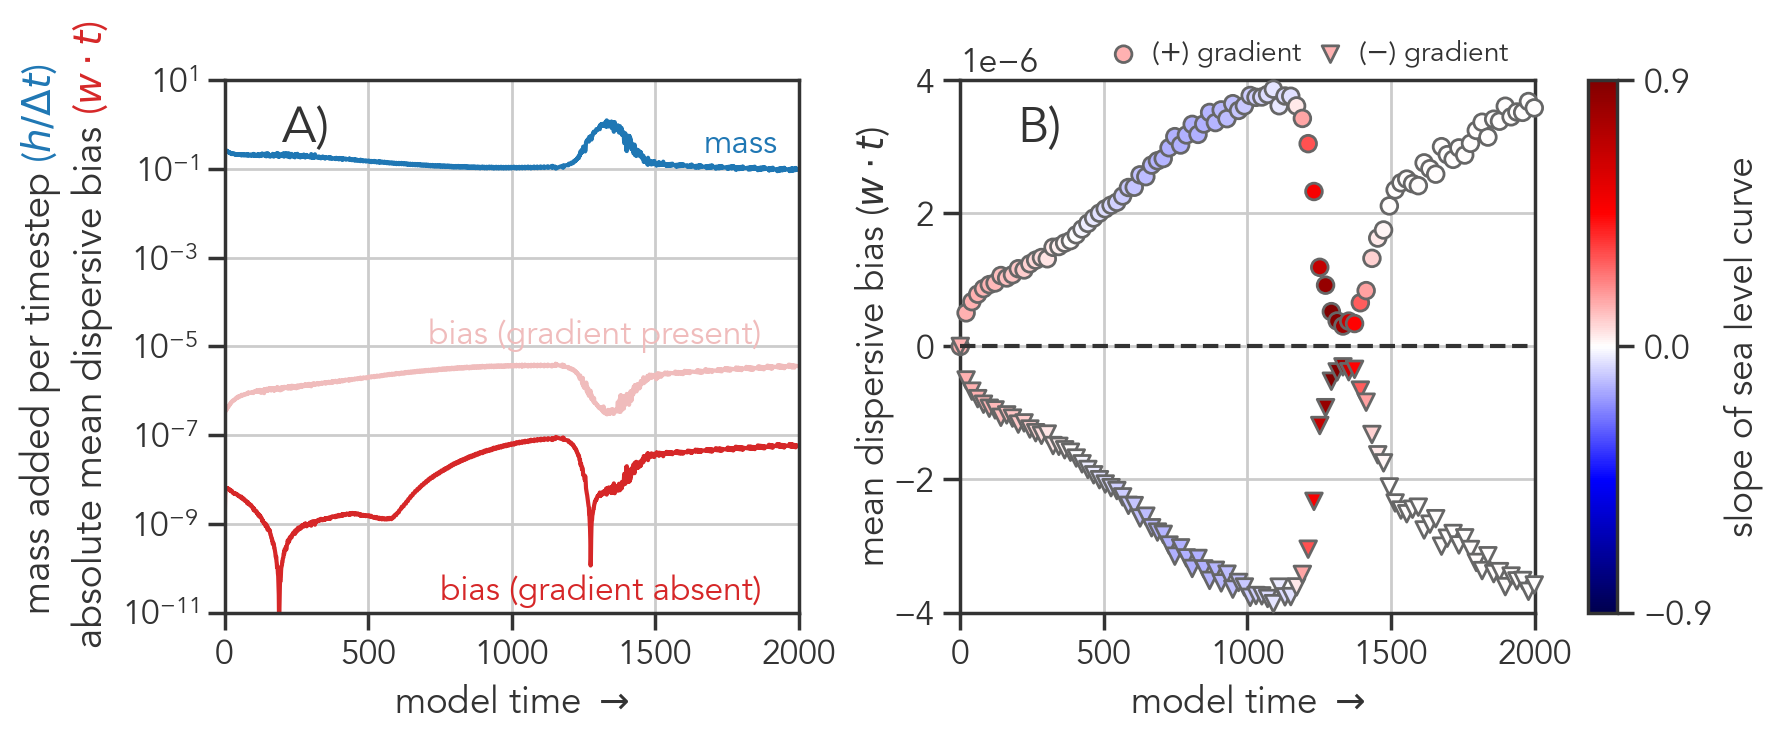

In [28]:
# changed model to not make bias absolute, but as showing magnitude differences here, will make absolute
sk = 0

# no gradient
bias = out_c.biastot[sk:]
bias_abs = np.abs(out_c.biastot[sk:])
massdt = out_c.massdt[sk:]

# gradient (positive)
bias_g = out_d.biastot[sk:]
bias_g_abs = np.abs(out_d.biastot[sk:])
massdt_g = out_d.massdt[sk:]

# gradient (negative); not plotting here as when absolute, same as postive one
bias_r = out_r.biastot[sk:]
bias_r_abs = np.abs(out_r.biastot[sk:])
massdt_r = out_r.massdt[sk:]

# downsample via interpolation so dashed vs solid lines can be clear. Major trends are still preserved
ilen = 100
bx,by = interp_vals(bias,ilen=ilen)
gx,gy = interp_vals(bias_g,ilen=ilen)
rx,ry = interp_vals(bias_r,ilen=ilen)
sx,sy = interp_vals(mod_c['rsl_strat'],ilen=ilen)

# gx = np.arange(len(bias_g))
# gy = bias_g
# rx = np.arange(len(bias_r))
# ry = bias_r
# sx = np.arange(len(mod_c['rsl_strat']))
# sy = mod_c['rsl_strat']
nm = np.gradient(sy) / np.gradient(sx)[0]

fig,ax = plt.subplot_mosaic(
    """
    abc
    """,width_ratios=[1,1,.05],figsize=(8.8, 3.6),layout='constrained')

# direction of bias
# scatter plot with diverging colormap
cmap = 'seismic'
im = ax['b'].scatter(gx, gy, c=nm, cmap=cmap, edgecolor='.4', marker='o',
                 vmin=-np.max(np.abs(nm)), vmax=np.max(np.abs(nm)),zorder=10000,label='($+$) gradient',clip_on=False)
_ = ax['b'].scatter(rx, ry, c=nm, cmap=cmap, edgecolor='.4', marker='v',
                 vmin=-np.max(np.abs(nm)), vmax=np.max(np.abs(nm)),zorder=10000,label='($-$) gradient',clip_on=False)  
ax['b'].legend(frameon=False,ncols=2,handlelength=1, columnspacing=0.5, handletextpad=0.5,loc=1,bbox_to_anchor=(1,1.125))

# colorbar centered at 0
cbar = plt.colorbar(im,cax=ax['c'],location='right')
cbar.ax.set_ylabel('slope of sea level curve')
cbar.ax.set_yticks([-0.9,0,0.9])
cbar.ax.set_ylim(-0.9,0.9)
ax['b'].axhline(0,ls='--',color='.2',zorder=10000)
ax['b'].grid(ls='-',zorder=0)
ax['b'].set_xlim(0,2000)
ax['b'].set_ylim(-4e-6,4e-6)
ax['b'].set_ylabel(r'mean dispersive bias ($w \cdot t$)',labelpad=-1)
#ax['b'].yaxis.tick_right()
#ax['b'].yaxis.set_label_position('right')
ax['b'].set_xlabel(r'model time $\rightarrow$')

# bias magnitude
# format
ax['a'].grid(ls='-')
ax['a'].set_xlabel(r'model time $\rightarrow$')
ax['a'].set_xlim(0,2000)

# plot mass per dt
ax['a'].plot(massdt,color='tab:blue',label='added mass/dt')
ax['a'].set_ylim(1e-11,1e1)
# #axa.set_ylabel('mass added per timestep ($h/dt$)',color='tab:blue')

# plot bias
gcol = '#f0bcbc' #'#e39695' # sns.color_palette('RdBu').as_hex()[1]
ax['a'].plot(bias_g_abs,color=gcol,label='bias with gradient')
#ax['a'].plot(bias_r_abs,color='tab:red',label='bias without gradient (reverse)') # identical to positive gradient as bias calculations are abs
ax['a'].plot(bias_abs,color='tab:red',label='bias without gradient')

#ax['a'].set_ylim(1e-11,1e-5)
#ax['a'].set_ylabel(r'mean dispersive bias ($w \cdot t$)',color='tab:red')
#ax['a'].set_ylabel('mean dispersive bias ($w \cdot t$);\nmass added per timestep ($h/dt$)')#,color='tab:red')
ax['a'].set_yscale('log')
#ax['a'].legend(handlelength=1, columnspacing=0.5, handletextpad=0.5,bbox_to_anchor=(0.025,0.65))

# annotate
ax['a'].text(0.835,0.865,'mass',color='tab:blue',transform=ax['a'].transAxes,fontsize=12)
ax['a'].text(0.355,0.505,'bias (gradient present)',color=gcol,transform=ax['a'].transAxes,fontsize=12)
ax['a'].text(0.375,0.025,'bias (gradient absent)',color='tab:red',transform=ax['a'].transAxes,fontsize=12)

# manual y label

label_style = ax['a'].xaxis.label.get_fontproperties()
label_color = ax['a'].xaxis.label.get_color()

# hide the regular y-axis label
ax['a'].set_ylabel('')

# bias label (black text)
ax['a'].text(-0.23, 0.425, 'absolute mean dispersive bias', transform=ax['a'].transAxes,
        rotation=90, va='center', ha='center', fontsize=14,fontproperties=label_style,color=label_color)

# bias units (red)
ax['a'].text(-0.23, 1.025, '($w \\cdot t$)', transform=ax['a'].transAxes,
        color='tab:red', rotation=90, va='center', ha='center', fontsize=14,fontproperties=label_style)

# mass label (black text)
ax['a'].text(-0.32, 0.4125, 'mass added per timestep', transform=ax['a'].transAxes,
        rotation=90, va='center', ha='center', fontsize=14,fontproperties=label_style,color=label_color)

# mass units (blue)
ax['a'].text(-0.32, 0.94, '($h/\\Delta t$)', transform=ax['a'].transAxes,
        color='tab:blue', rotation=90, va='center', ha='center', fontsize=14,fontproperties=label_style)

# label
labs = string.ascii_uppercase[:2]
for a,l in zip(list(ax),labs):
    ax[a].text(0.1, 0.885, f'{l})', transform=ax[a].transAxes, fontsize=18)

# save figure
fig.savefig(tex_fig_dir + 'disperse.pdf', format='pdf', bbox_inches='tight', transparent=False)